# Momentum & Value Strategy Backtester — Phase 2

**Strategy:** long-only, equal-weight, quarterly-rebalanced value composite on the S&P 500 —
a cross-sectional blend of P/B, P/E, EV/EBITDA, and a trailing-growth-adjusted value factor.

**Why quarterly, not monthly?** Fundamentals only change when a company files a new 10-Q/10-K.
Rebalancing monthly (like the Phase 1 momentum strategy) would mostly churn turnover and costs
against stale, unchanged ratios, so this strategy rebalances on the same cadence its underlying
data actually updates.

**Why SEC EDGAR, not yfinance?** yfinance only exposes today's snapshot fundamentals — applying
2026's P/E to a 2013 rebalance decision would be a serious look-ahead bias. SEC EDGAR's XBRL
"company facts" API reports the actual date every figure was **filed**, which is what lets this
notebook enforce the same no-look-ahead discipline the momentum strategy applies to prices and
index membership: a fact is only used for a decision on date *t* if it was filed on or before *t*.

**Why percentile ranks, not z-scores?** P/E and EV/EBITDA both have earnings-like figures in the
denominator, which can be near-zero for perfectly ordinary S&P 500 companies in a weak quarter —
producing wild outlier ratios. Percentile ranks only use ordering, so one extreme value can't
distort the score for every other stock the way it would with a mean/stdev-based z-score.

**Why isn't the fourth factor called PEG?** Real PEG divides P/E by a *forward* analyst
consensus growth estimate — a live market expectation. That data isn't available point-in-time
for free. This notebook uses **realized historical (trailing) EPS growth** instead, which is a
different, weaker signal (past growth doesn't reliably predict future growth), and is named
"growth-adjusted value" rather than PEG to keep that distinction honest.

**Loss-making companies are kept in the universe**, not filtered out. Instead, a non-positive
ratio (negative P/E, negative EV/EBITDA, shrinking or negative earnings) is deliberately ranked
as the *least* attractive end of that metric — a loss-making company shouldn't look artificially
cheap just because a ratio's sign flipped.

**No parameters here were tuned to this dataset.** The headline spec (P/B + P/E + EV/EBITDA +
growth-adjusted value, quarterly, top 50, 10bps) reflects design decisions made and justified
*before* seeing this notebook's results — see the project chat history for the full reasoning
behind each choice. A robustness appendix at the end reruns nearby parameter choices to show the
result isn't a fragile, cherry-picked one-off.


## 1. Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import replace

import pandas as pd

# Allow `import src.*` when this notebook is run from the notebooks/ directory.
sys.path.append(str(Path("..").resolve()))

from src.config import DEFAULT_VALUE_CONFIG
from src.data_layer.constituents import load_constituents_table, get_membership
from src.data_layer.prices import get_prices
from src.data_layer.fundamentals import load_ticker_cik_map, get_fundamentals_facts, get_point_in_time_fundamentals
from src.strategy.value import compute_value_ratios, compute_composite_score, select_top_n
from src.backtest.value_engine import run_value_backtest, compute_value_benchmark_result
from src.evaluation.metrics import summary_table, cagr, sharpe_ratio, max_drawdown
from src.evaluation.plots import plot_equity_curves, plot_drawdown, plot_universe_size

config = DEFAULT_VALUE_CONFIG
print(config)


ValueBacktestConfig(start_date='2012-01-01', end_date='2026-06-30', rebalance_freq='QE', top_n=50, benchmark_ticker='SPY', risk_free_rate=0.0, one_way_cost_bps=10.0, price_outlier_threshold=0.5, cache_dir=WindowsPath('C:/Users/arwga/Developer/ClaudeProjects/Trading/MomentumValueStrategy/data/cache'), constituents_url='https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv')


## 2. Point-in-time universe

Same point-in-time S&P 500 membership data the momentum strategy uses (see
`src/data_layer/constituents.py`) — reused as-is rather than rebuilt, and deliberately the same
date window as Phase 1, so the two strategies are directly comparable rather than differing for
incidental reasons.


In [2]:
constituents_table = load_constituents_table(cache_dir=config.cache_dir, url=config.constituents_url)

requested_rebalance_dates = pd.date_range(config.start_date, config.end_date, freq=config.rebalance_freq)
print(f"{len(requested_rebalance_dates)} quarterly rebalance dates from {config.start_date} to {config.end_date}")

all_tickers = set()
for d in requested_rebalance_dates:
    all_tickers.update(get_membership(d, constituents_table))
print(f"{len(all_tickers)} distinct tickers were ever an S&P 500 constituent during this window")


58 quarterly rebalance dates from 2012-01-01 to 2026-06-30
809 distinct tickers were ever an S&P 500 constituent during this window


## 3. Price and fundamentals data

Two independent data layers feed the value composite: prices (reused from the momentum work,
`src/data_layer/prices.py`) and fundamentals (new for this phase, `src/data_layer/fundamentals.py`).
Unlike momentum, the value signal needs no price *history* before the first rebalance — it's not
a lookback-return calculation, just a price snapshot at each formation date — so prices are
fetched from `config.start_date` directly, with no warmup offset.


In [3]:
daily_prices, price_failed_tickers = get_prices(
    sorted(all_tickers | {config.benchmark_ticker}), config.start_date, config.end_date, cache_dir=config.cache_dir
)
print(f"Prices: succeeded for {daily_prices.shape[1]} tickers, failed for {len(price_failed_tickers)}")


$CVC: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$ANRZQ: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$APOL: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$CVH: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$BXLT: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


...

$WPX: possibly delisted; no timezone found



19 Failed downloads:


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


['WCG', 'XL', 'VIAB', 'TWTR', 'XLNX', 'XEC', 'WIN', 'WLTW', 'WRK', 'TSS', 'VAR', 'UTX', 'X', 'WBA', 'WYND', 'VIAC', 'WPX']: possibly delisted; no timezone found


Prices: succeeded for 641 tickers, failed for 169


In [4]:
cik_map = load_ticker_cik_map(config.cache_dir)
facts_by_ticker, fundamentals_failed_tickers = get_fundamentals_facts(sorted(all_tickers), config.cache_dir, cik_map=cik_map)

print(f"Fundamentals: found SEC filing history for {len(facts_by_ticker)} of {len(all_tickers)} tickers")
print(f"Failed: {len(fundamentals_failed_tickers)} tickers (no CIK match, or no XBRL data on file)")
print("Sample failed tickers:", fundamentals_failed_tickers[:15])

# Coverage caveat (see fundamentals.py's module docstring): SEC's ticker->CIK
# mapping only covers companies CURRENTLY registered with the SEC, so an
# older S&P 500 constituent that was acquired/delisted years ago may not
# appear in it at all, even though it's a valid point-in-time constituent.
# This is a real, disclosed limitation, not a bug - it reintroduces a
# data-coverage-driven echo of the survivorship bias the price/momentum
# side of this project otherwise avoids.
coverage_pct = len(facts_by_ticker) / len(all_tickers)
print(f"\nFundamentals coverage: {coverage_pct:.1%} of the point-in-time universe")


Fundamentals: found SEC filing history for 612 of 809 tickers
Failed: 197 tickers (no CIK match, or no XBRL data on file)
Sample failed tickers: ['AABA', 'ABC', 'ABMD', 'ADS', 'AET', 'AGN', 'ALTR', 'ALXN', 'ANDV', 'ANRZQ', 'ANSS', 'ANTM', 'APOL', 'ARG', 'ARNC']

Fundamentals coverage: 75.6% of the point-in-time universe


## 4. Value composite, illustrated

Before running the full backtest, let's compute the composite score for one rebalance date by
hand, to make the mechanics completely concrete: raw ratios, then percentile ranks, then the
averaged composite.


In [5]:
quarter_end_prices = daily_prices.resample(config.rebalance_freq).last()
example_date = quarter_end_prices.index[quarter_end_prices.index >= pd.Timestamp(config.start_date)][0]
print(f"Example formation date: {example_date.date()}")

membership_example = get_membership(example_date, constituents_table)
fundamentals_example = {
    ticker: get_point_in_time_fundamentals(facts_by_ticker[ticker], example_date)
    for ticker in membership_example
    if ticker in facts_by_ticker
}
priceable_example = [t for t in membership_example if t in quarter_end_prices.columns]
prices_example = quarter_end_prices.loc[example_date, priceable_example]
prices_example = {t: p for t, p in prices_example.items() if pd.notna(p)}

raw_ratios_example = compute_value_ratios(fundamentals_example, prices_example)
print(f"\n{len(raw_ratios_example)} tickers with a price and at least some fundamental data:")
raw_ratios_example.describe()


Example formation date: 2012-03-31



311 tickers with a price and at least some fundamental data:


C:\Users\arwga\Developer\ClaudeProjects\Trading\MomentumValueStrategy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
C:\Users\arwga\Developer\ClaudeProjects\Trading\MomentumValueStrategy\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,pb,pe,ev_ebitda,growth_adjusted_value
count,293.000000,306.000000,138.000000,303.000000
mean,5.104973,14.194608,8.662259,inf
std,43.206487,62.810512,14.773728,NaN
min,-68.195445,-421.895387,-3.402807,0.263006
25%,0.738779,6.231757,4.300894,22.559722
50%,1.416088,9.736014,6.173925,75.068191
75%,2.609029,14.713962,8.347806,NaN
max,648.156723,911.226747,133.337431,inf


In [6]:
composite_example = compute_composite_score(raw_ratios_example)

print("Cheapest 10 (lowest composite score):")
print(composite_example.sort_values(ascending=True).head(10))
print("\nMost expensive 10 (highest composite score):")
print(composite_example.sort_values(ascending=False).head(10))
print(f"\n{composite_example.notna().sum()} of {len(composite_example)} tickers scored "
      f"(the rest had fewer than MIN_AVAILABLE_METRICS ratios available)")


Cheapest 10 (lowest composite score):
BRK-B    0.003340
NVDA     0.006654
AAPL     0.015206
NFLX     0.017757
CME      0.023166
CF       0.035954
BKNG     0.052467
ORLY     0.053890
MPC      0.055205
APH      0.068033
dtype: float64

Most expensive 10 (highest composite score):
MAR    0.924166
EIX    0.914272
HSY    0.899384
NBR    0.893607
CRM    0.882552
RRC    0.877299
CCI    0.874552
MAS    0.874211
WMB    0.869197
GE     0.864741
dtype: float64

307 of 311 tickers scored (the rest had fewer than MIN_AVAILABLE_METRICS ratios available)


## 5. Full backtest run

In [7]:
result = run_value_backtest(config)

avg_holdings = sum(len(h) for h in result.holdings_history.values()) / len(result.holdings_history)
print(f"Rebalances: {len(result.gross_returns)}")
print(f"Average holdings per quarter: {avg_holdings:.1f} (target: {config.top_n})")
print(f"Average quarterly turnover: {result.turnover_history.mean():.1%}")
print(f"Missing forward-price occurrences (delistings mid-holding / data gaps): {result.missing_forward_price_count}")
print(f"Extreme-return exclusions (implausible >300% single-quarter gain, treated as a vendor data glitch): {result.extreme_return_count}")
print(f"Failed tickers (no price or no fundamentals data): {len(result.failed_tickers)}")


$BXLT: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$APOL: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$CVC: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$CVH: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$ANRZQ: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


...

$XLNX: possibly delisted; no timezone found



19 Failed downloads:


['WFM', 'TWC']: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


['WCG', 'WBA', 'WLTW', 'XEC', 'WYND', 'VIAB', 'WPX', 'TSS', 'WRK', 'XL', 'VIAC', 'VAR', 'WIN', 'UTX', 'X', 'TWTR', 'XLNX']: possibly delisted; no timezone found


Rebalances: 57
Average holdings per quarter: 50.0 (target: 50)
Average quarterly turnover: 24.7%
Missing forward-price occurrences (delistings mid-holding / data gaps): 0
Extreme-return exclusions (implausible >300% single-quarter gain, treated as a vendor data glitch): 0
Failed tickers (no price or no fundamentals data): 197


## 6. Benchmark: SPY buy-and-hold

In [8]:
benchmark_returns, benchmark_equity = compute_value_benchmark_result(config)
print(f"SPY equity (quarterly), start: {benchmark_equity.iloc[0]:.3f}, end: {benchmark_equity.iloc[-1]:.3f}")


SPY equity (quarterly), start: 0.972, end: 6.744


## 7. Evaluation: Strategy (Gross) vs. Strategy (Net of costs) vs. Benchmark

`periods_per_year=4` is passed explicitly here since these are quarterly, not monthly, returns —
`sharpe_ratio`/`annualized_vol` need this to annualize correctly (they default to 12 for
momentum's monthly cadence).


In [9]:
table = summary_table(
    result.gross_returns, result.gross_equity,
    result.net_returns, result.net_equity,
    benchmark_returns, benchmark_equity,
    risk_free_rate=config.risk_free_rate,
    periods_per_year=4,
)
table


,Strategy (Gross),Strategy (Net of costs),Benchmark
CAGR,0.161140,0.159037,0.148441
Annualized Volatility,0.170749,0.170851,0.142846
Sharpe Ratio,0.943537,0.931422,1.024861
Max Drawdown,-0.337243,-0.337643,-0.239272


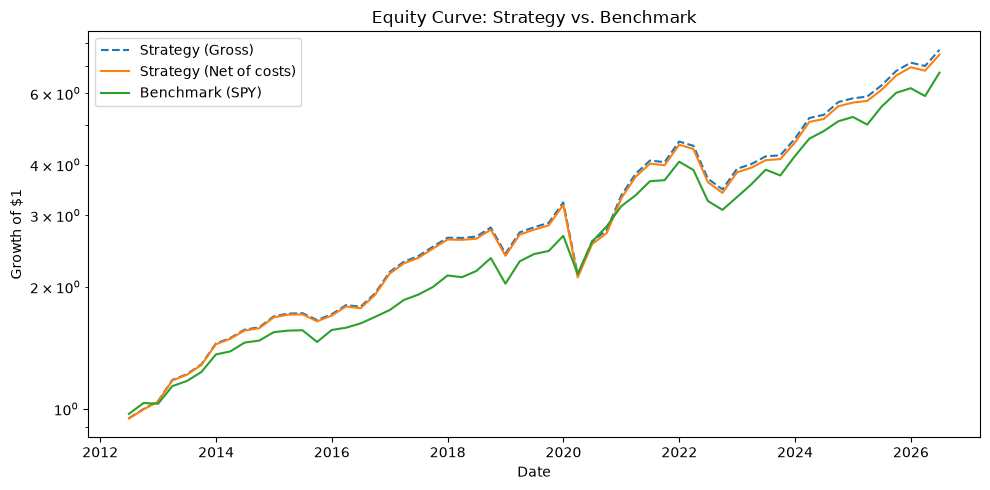

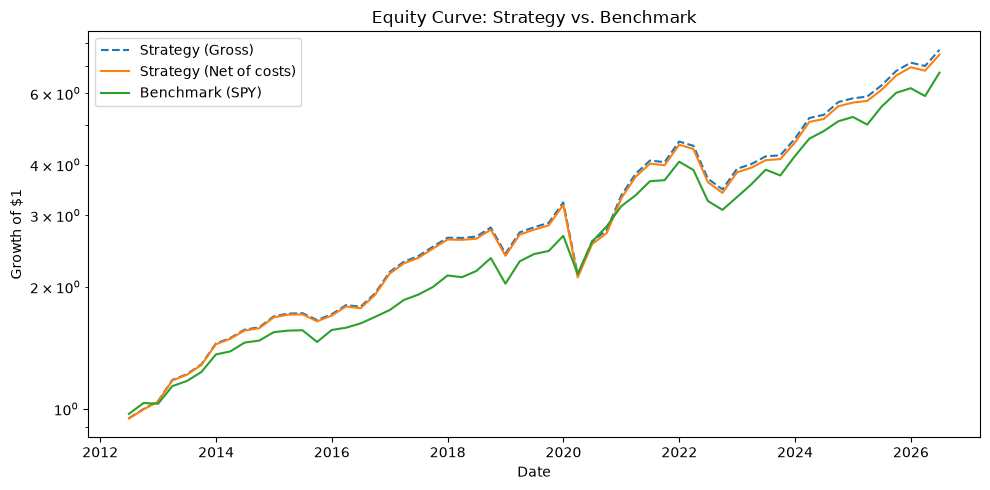

In [10]:
plot_equity_curves(result.gross_equity, result.net_equity, benchmark_equity, log_scale=True)


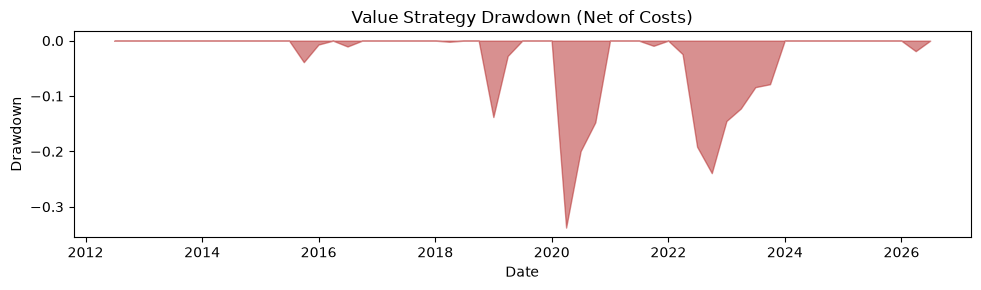

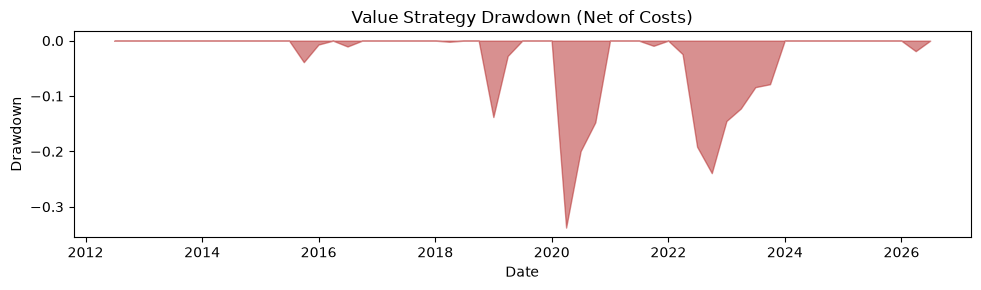

In [11]:
plot_drawdown(result.net_equity, title="Value Strategy Drawdown (Net of Costs)")


## 8. Data coverage diagnostics

Worth inspecting directly rather than assuming the composite is well-formed for every stock every
quarter — in particular, EV/EBITDA is structurally unavailable for financial companies (banks
don't report a standard "operating income" the way industrials do), which was confirmed against
real SEC data for JPMorgan during development.


In [12]:
# How often was each of the four metrics actually available across the full universe,
# at the example date computed in Section 4 - a representative single-period snapshot.
coverage_counts = raw_ratios_example.notna().sum()
coverage_pct = raw_ratios_example.notna().mean()
pd.DataFrame({"available_count": coverage_counts, "available_pct": coverage_pct})


,available_count,available_pct
pb,293,0.942122
pe,306,0.983923
ev_ebitda,138,0.443730
growth_adjusted_value,303,0.974277


## 9. Robustness appendix: is this result fragile?

The headline result above uses the pre-committed specification — nothing here was tuned to
maximize this backtest's own Sharpe ratio. To guard against the result being a fragile, one-off
outcome, we rerun the backtest across a small grid of nearby, equally-reasonable parameter
choices and a range of transaction cost assumptions. We're looking for the *qualitative* pattern
(does net risk-adjusted return stay positive and in a similar ballpark) — not searching for, or
reporting, whichever cell in the grid looks best.

This grid is smaller (2x2) than the momentum notebook's (3x3x3): each variant here re-reads both
the price AND fundamentals caches (~1,500 files) from scratch, which is meaningfully slower per
run than momentum's price-only equivalent, so the grid is kept tighter to keep this notebook's
runtime reasonable rather than exhaustively searching every nearby combination.


In [13]:
robustness_rows = []

for top_n in [40, 50]:
    for cost_bps in [10.0, 20.0]:
        print(f"Running top_n={top_n}, cost_bps={cost_bps}...")
        variant_config = replace(config, top_n=top_n, one_way_cost_bps=cost_bps)
        variant_result = run_value_backtest(variant_config)
        robustness_rows.append({
            "top_n": top_n,
            "one_way_cost_bps": cost_bps,
            "net_CAGR": cagr(variant_result.net_equity),
            "net_Sharpe": sharpe_ratio(variant_result.net_returns, config.risk_free_rate, periods_per_year=4),
            "net_MaxDD": max_drawdown(variant_result.net_equity),
        })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df


Running top_n=40, cost_bps=10.0...


$BXLT: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$APOL: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$CVC: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


$ANRZQ: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


...

$WCG: possibly delisted; no timezone found



19 Failed downloads:


['TWC', 'WFM']: possibly delisted; no price data found  (1d 2012-01-01 -> 2026-06-30)


['TWTR', 'WYND', 'XLNX', 'UTX', 'XEC', 'XL', 'WLTW', 'WPX', 'WIN', 'WBA', 'X', 'VIAB', 'VIAC', 'VAR', 'TSS', 'WRK', 'WCG']: possibly delisted; no timezone found


,top_n,one_way_cost_bps,net_CAGR,net_Sharpe,net_MaxDD
0,40,10.0,0.166909,0.963264,-0.335587
1,40,20.0,0.164730,0.951063,-0.335987
2,50,10.0,0.159037,0.931422,-0.337643
3,50,20.0,0.156936,0.919304,-0.338043


In [14]:
print("Net Sharpe ratio range across all variants:", robustness_df["net_Sharpe"].min(), "to", robustness_df["net_Sharpe"].max())
print("Share of variants with positive net CAGR:", (robustness_df["net_CAGR"] > 0).mean())


Net Sharpe ratio range across all variants: 0.9193042171784834 to 0.963264124460865
Share of variants with positive net CAGR: 1.0


## 10. Limitations

Every design decision here should be explainable and defensible — including its limitations:

- **SEC EDGAR ticker coverage only includes CURRENTLY-registered filers.** A company acquired or
  delisted years ago may be entirely absent from the CIK mapping even though it's a valid
  point-in-time S&P 500 constituent, understating this backtest's universe relative to momentum's
  price-only universe. See Section 3's coverage percentage.
- **XBRL tagging is not standardized across companies.** This notebook tries several candidate
  tags per concept and picks whichever has the freshest data (see `fundamentals.py`), but some
  filers use non-standard or company-specific tags this can't follow. A concrete example found
  during development: Ford's real ~$150B of combined debt was captured correctly through 2017 via
  `DebtAndCapitalLeaseObligations`, but from 2018 onward Ford re-tagged in a way this module
  can't follow, and its `total_debt` silently understates from that point on.
- **EV/EBITDA is structurally unavailable for financial companies** (confirmed against real data
  for JPMorgan) - banks don't report a standard operating-income figure the way industrials do.
  Financials are still scored on their other available metrics (see MIN_AVAILABLE_METRICS in
  `src/strategy/value.py`), not excluded outright.
- **The growth-adjusted factor uses trailing (realized), not forward (expected), earnings
  growth**, and is deliberately NOT called PEG for exactly that reason - real PEG needs forward
  analyst consensus estimates that aren't available point-in-time for free. This is a different,
  weaker signal (past growth doesn't reliably predict future growth).
- **A non-positive EV/EBITDA is always treated as least-attractive**, even though it can
  occasionally arise from a company holding more net cash than its market cap plus debt - a
  classic deep-value "net-net" signal, arguably one of the cheapest possible situations rather
  than a bad one. This rule can't distinguish the two cases; see `_rank_lower_is_better()`'s
  docstring in `src/strategy/value.py`.
- **Total debt defaults to zero when no debt tag is found at all**, rather than being marked
  unknown - reasonable for large, disclosure-heavy S&P 500 filers, but combined with the
  non-standard-tagging limitation above, could understate EV for some companies.
- **Transaction costs, missing-forward-price handling, and the extreme-return vendor-glitch
  guard reuse the same assumptions and reasoning as the momentum strategy** (see
  `notebooks/01_momentum_backtest.ipynb`'s Limitations section for the full justification) -
  applied here without modification since the underlying questions (is a single-period return
  plausible for an S&P 500-type stock; how should a mid-holding delisting be handled) don't
  depend on which signal selected the stock.
- **Point-in-time constituents data is community-maintained, not an official index vendor feed**
  - see the momentum notebook's Limitations section for the same caveat, which applies equally
  here since both strategies share `src/data_layer/constituents.py`.

## 11. Conclusion

This notebook implements and evaluates a realistic, cost-aware, point-in-time value composite
strategy on the S&P 500, built on a from-scratch SEC EDGAR fundamentals data layer with an
explicit no-look-ahead invariant, and an explicit robustness check against overfitting. Designed
throughout to share the same universe, date window, and cost/evaluation assumptions as the Phase
1 momentum strategy, so the two can be compared directly once merged.
